In [1]:
from src.data.bayesian_b_updater import BayesianGRBUpdater# %%
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 

In [2]:
args= load_args_from_yaml("../config/mixer_tpp.yaml")
args.dataset = 'ChuanDian'
base_dir = f"../data/{args.dataset}"
# %%
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Using catalog dataset class: <class 'src.catalogs.chuandian.ChuanDianStandard'>
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.
Number of training events: 4498
Number of validation events: 567


In [3]:
seq.mag

tensor([5.2000, 4.4000, 4.3000,  ..., 3.2000, 3.2000, 3.3000])

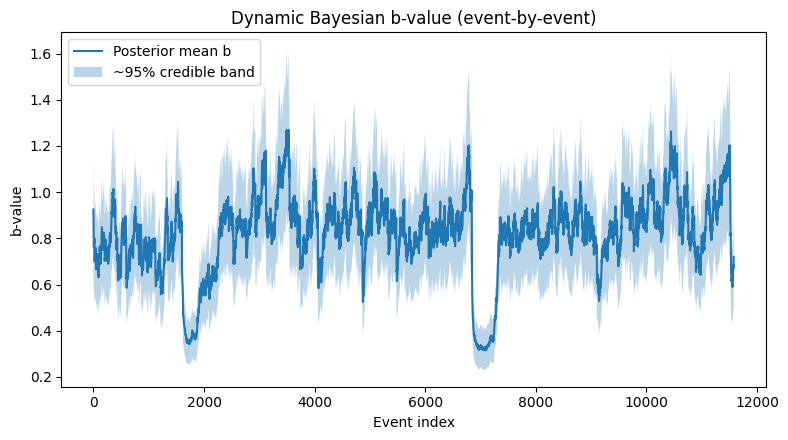

In [6]:
updater = BayesianGRBUpdater(Mc=3, delta=0.98, a0=50, init_b_target=1, mag_key="mag", write_back=True)
results = updater.fit(seq)       # 逐事件更新；同时把结果字段写回0 seq
BayesianGRBUpdater.plot(seq)          # 绘图（可选传入 truth_lines / switch_index）

似然最大取值与Gamma分布期望的差异

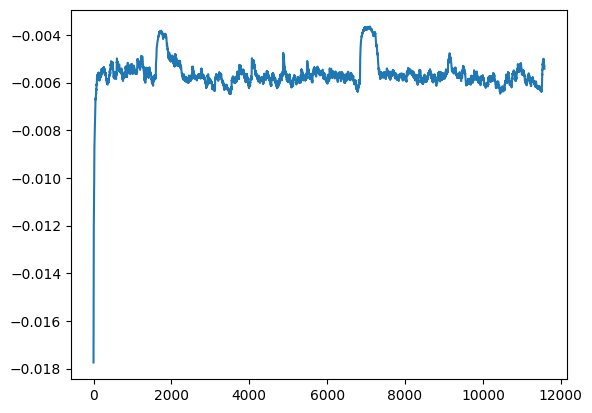

In [5]:
import math
import matplotlib.pyplot as plt
diff = (seq.a_t-1)/(math.log(10)*seq.s_t)-(seq.a_t)/(math.log(10)*seq.s_t)  
# diff.mean()
# diff.max()
plt.plot(diff)